<a href="https://colab.research.google.com/github/yyred-max/Analisis_Data_Eksploratif/blob/main/Latihan9_Yuliana.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
df = pd.read_csv('https://raw.githubusercontent.com/PacktPublishing/hands-on-exploratory-data-analysis-with-python/master/Chapter%207/automobile.csv')
df.head(10)

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450
5,2,?,audi,gas,std,two,sedan,fwd,front,99.8,...,136,mpfi,3.19,3.4,8.5,110,5500,19,25,15250
6,1,158,audi,gas,std,four,sedan,fwd,front,105.8,...,136,mpfi,3.19,3.4,8.5,110,5500,19,25,17710
7,1,?,audi,gas,std,four,wagon,fwd,front,105.8,...,136,mpfi,3.19,3.4,8.5,110,5500,19,25,18920
8,1,158,audi,gas,turbo,four,sedan,fwd,front,105.8,...,131,mpfi,3.13,3.4,8.3,140,5500,17,20,23875
9,0,?,audi,gas,turbo,two,hatchback,4wd,front,99.5,...,131,mpfi,3.13,3.4,7.0,160,5500,16,22,?


In [ ]:
df.dtypes

,0
symboling,int64
normalized-losses,object
make,object
fuel-type,object
aspiration,object
num-of-doors,object
body-style,object
drive-wheels,object
engine-location,object
wheel-base,float64


In [ ]:
mean = df["height"].mean()
median = df["height"].median()
mode = df["height"].mode()
print(mean, median, mode)

53.72487804878049 54.1 0    50.8
Name: height, dtype: float64


In [ ]:
#CLEANING DATA PRICE
# Find out the number of values which are not numeric
df['price'].str.isnumeric().value_counts()

# List out the values which are not numeric
df['price'].loc[df['price'].str.isnumeric() == False]

#Setting the missing value to mean of price and convert the datatype to integer
price = df['price'].loc[df['price'] != '?']
pmean = price.astype(int).mean()
df['price'] = df['price'].replace('?',pmean).astype(int)
df['price'].head()

,price
0,13495
1,16500
2,16500
3,13950
4,17450


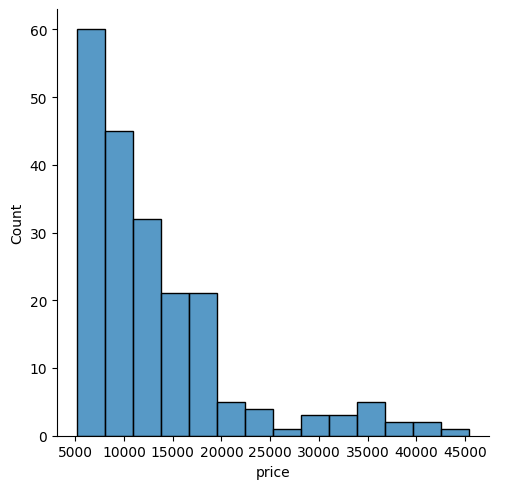

In [ ]:
#distribution plot
#sns.FacetGrid(df,size=5).map(sns.displot, "price").add_legend()
g = sns.FacetGrid(df, height=5)
g.map(sns.histplot, "price").add_legend()
plt.show()

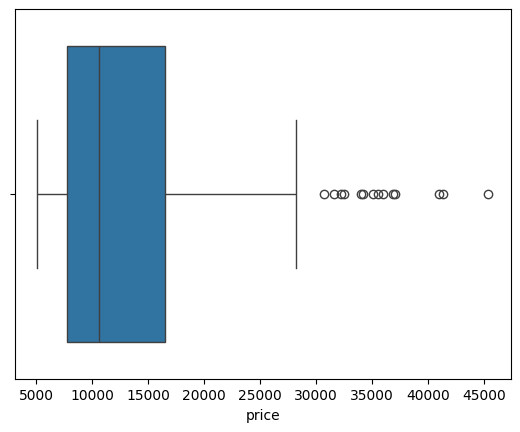

In [ ]:
#boxplot for price of cars
sns.boxplot(x="price", data=df)
plt.show()

Text(0, 0.5, 'Horsepower')

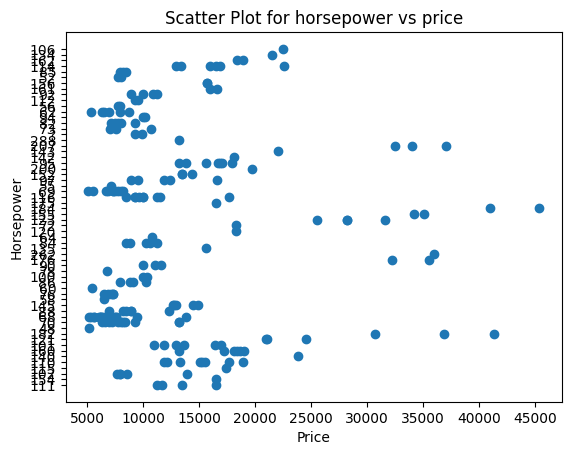

In [ ]:
# plot the relationship between "horsepower" and "price"
plt.scatter(df["price"], df["horsepower"])
plt.title("Scatter Plot for horsepower vs price")
plt.xlabel("Price")
plt.ylabel("Horsepower")

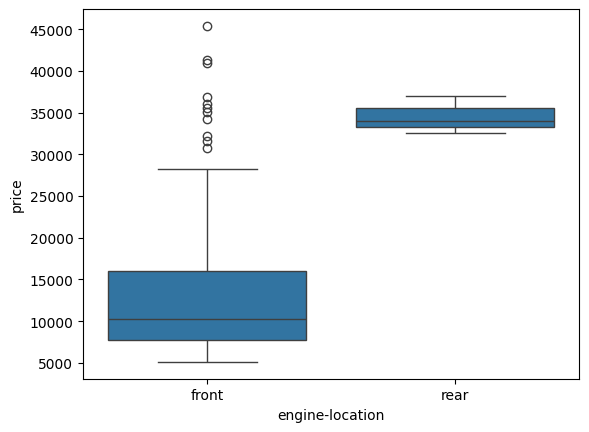

In [ ]:
#boxplot
sns.boxplot(x="engine-location", y="price", data=df)
plt.show()

<Axes: xlabel='drive-wheels', ylabel='price'>

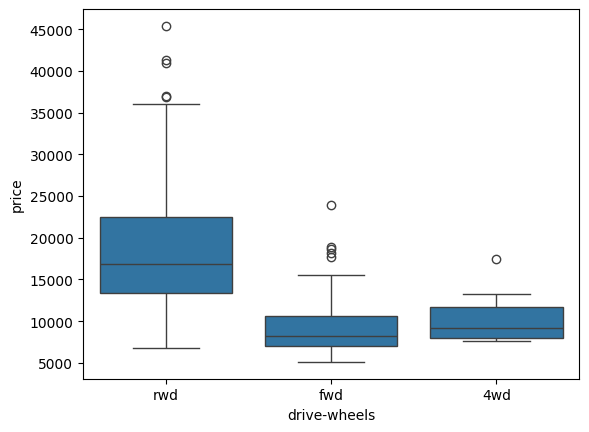

In [ ]:
#boplot to visualize the distribution of "price" with types of "drive-wheels"
sns.boxplot(x="drive-wheels", y="price", data=df)

KeyError: 'normalized=losses'

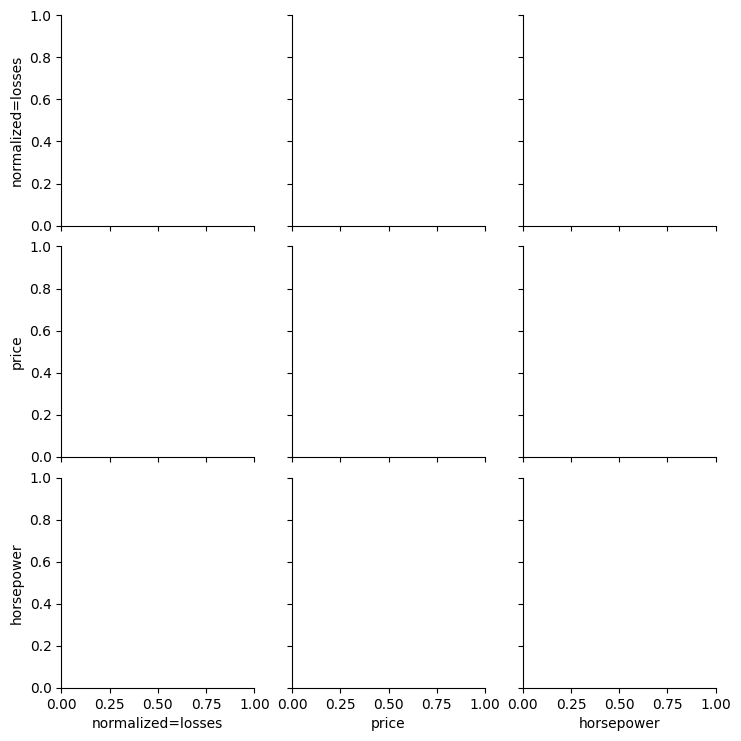

In [ ]:
#pair plot with plot type regression
sns.pairplot(df, vars=['normalized=losses', 'price', 'horsepower'], kind="reg")
plt.show()
#Hasil running dari plot tersebut error karena tipe data yang diplot berbeda,
#sehingga kita perlu melakukan cleaning data yaitu mengubah tipe data menjadi integer

In [ ]:
# Cleaning the horsepower losses field
df['horsepower'].str.isnumeric().value_counts()
horsepower = df['horsepower'].loc[df['horsepower'] != '?']
hpmean = horsepower.astype(int).mean()
df['horsepower'] = df['horsepower'].replace('?', hpmean).astype(int)
df['horsepower'].head()

,horsepower
0,111
1,111
2,154
3,102
4,115


In [ ]:
#Cleaning the normalized losses field
df[df['normalized-losses']=='?'].count()
nl=df['normalized-losses'].loc[df['normalized-losses'] != '?']
nmean=nl.astype(int).mean()
df['normalized-losses'] = df['normalized-losses'].replace('?', nmean).astype(int)
df['normalized-losses'].head()

,normalized-losses
0,122
1,122
2,122
3,164
4,164


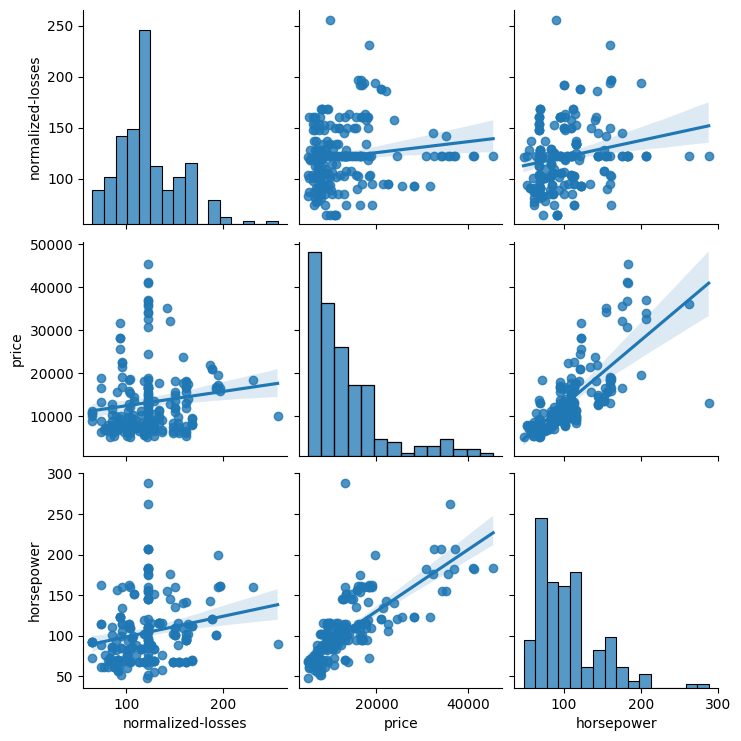

In [ ]:
# pair plot with plot type regression
sns.pairplot(df, vars = ['normalized-losses', 'price', 'horsepower'], kind="reg")
plt.show()

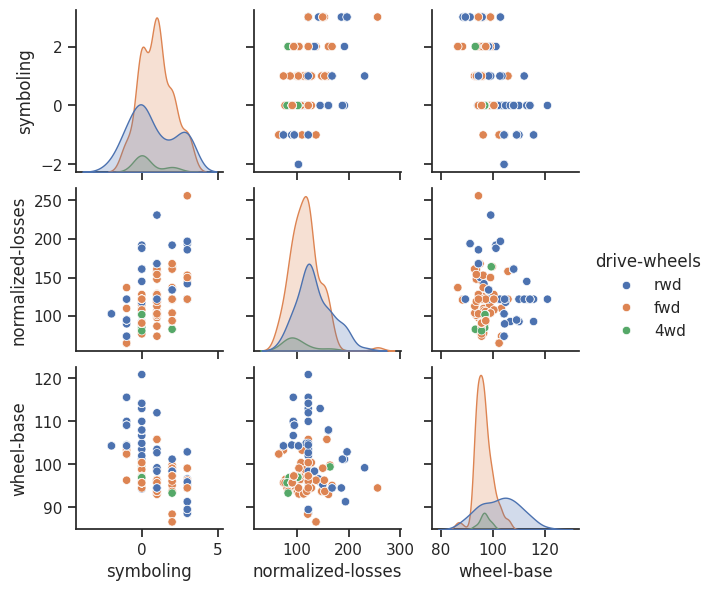

In [ ]:
#pair plot (matrix scatterplot) of few columns
sns.set(style="ticks", color_codes=True)
sns.pairplot(df, height=2, vars =
  ['symboling', 'normalized-losses', 'wheel-base'], hue="drive-wheels")
plt.show()

In [ ]:
from scipy import stats
corr = stats.pearsonr(df["price"], df["horsepower"])
print("p-value:\t", corr[1])
print("cor:\t\t", corr[0])

p-value:	 1.5910332446595894e-39
cor:		 0.757945621793524
